# 16. Clasificación de textos con Redes Neuronales y Embeddings preentrenados

Este notebook resuelve **el mismo problema** que `15_MLP_clasificacion_textos.ipynb` —clasificar el sentimiento de críticas de FilmAffinity en Negativa, Neutra o Positiva con un Perceptrón Multicapa—, cambiando **una sola pieza** del pipeline: en vez de representar los textos con Bag of Words, usamos el embedding preentrenado de 128 dimensiones (`nnlm-es-dim128`) que ya vimos en `13_Ejemplo_embeddings_preentrenados.ipynb` y `14_busqueda_semantica_embeddings.ipynb`.

La diferencia clave está en cómo representamos cada documento:

- **Notebook 15**: cada crítica es un vector **sparse** de 3.000 posiciones (Bag of Words), la mayoría de ellas a cero.
- **Notebook 16**: cada crítica es un vector **denso** de solo 128 posiciones, generado por el embedding preentrenado — 23 veces más pequeño, y aprendido a partir de una cantidad de texto mucho mayor de la que tenemos aquí.

La hipótesis de partida es que ese vector denso, al capturar significado en lugar de simples frecuencias de palabras, debería producir un modelo con mejores métricas que el del notebook 15. Como veremos en las conclusiones, esa hipótesis sí se cumple, aunque con un margen modesto y un coste computacional considerable.

La red tendrá el embedding como **primera capa** de la propia red neuronal (no como un paso de preprocesado aparte), seguida exactamente de la misma red clasificadora que usamos en el notebook 15. Como todos los conceptos de esa parte (arquitectura del MLP, Dropout, *class_weight*, *epochs*, *batch size*, el *callback* de F1, TensorFlow-Keras...) ya se explicaron allí con detalle, aquí solo los mencionaremos de paso; nos centramos en lo nuevo: el embedding como capa de la red y la normalización ligera que le corresponde.

En la siguiente imagen podemos ver un esquema de la arquitectura de red que usaremos:

<img src="imgs/012_red_neuronal_arquitectura.png" style="width: 900px;"/>

Los pasos que vamos a dar son loa siguientes:

1. Cargar los datos
2. Normalizar los textos (ahora con normalización ligera, no con BoW)
3. Particionado de datos (Train y Test)
4. Codificación del target (ya no hay bolsa de palabras)
5. Definición de la Red Neuronal (con el embedding como primera capa)
6. Entrenamiento de la Red Neuronal
7. Evaluación del modelo, comparando con el notebook 15

---

## 1. Carga de datos

Igual que en el notebook 15: cargamos `corpus/reviews_filmaffinity.csv`, derivamos el sentimiento a partir de `review_rate` (Negativa ≤ 4, Neutra 5-6, Positiva ≥ 7) y usamos como texto de entrada la concatenación de `review_title` y `review_text`. El dataset sigue igual de desbalanceado que en el notebook 15 (Positiva 45.6 %, Negativa 28.5 %, Neutra 26.0 %).

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'       # silencia mensajes informativos de TensorFlow
os.environ['TF_USE_LEGACY_KERAS'] = '1'        # necesario para usar hub.KerasLayer como capa de un modelo (ver seccion 5)

import pandas as pd

df = pd.read_csv('corpus/reviews_filmaffinity.csv', sep='\|\|', engine='python')
df = df.dropna(subset=['review_rate'])
df['texto'] = df['review_title'].fillna('') + '. ' + df['review_text'].fillna('')

def nota_a_sentimiento(nota):
    if nota <= 4:
        return 'Negativa'
    elif nota <= 6:
        return 'Neutra'
    else:
        return 'Positiva'

df['sentimiento'] = df['review_rate'].apply(nota_a_sentimiento)

print(f'Total de criticas: {len(df)}')
print(df['sentimiento'].value_counts())

Total de criticas: 8601
sentimiento
Positiva    3920
Negativa    2447
Neutra      2234
Name: count, dtype: int64


---

## 2. Normalización de los textos

Aquí está el primer cambio importante respecto al notebook 15. Allí normalizábamos de forma agresiva con spaCy (minúsculas, lematización, eliminación de *stopwords*, puntuación y acentos) porque construíamos una Bag of Words y nos interesaba reducir el vocabulario.

Ahora vamos a alimentar la red con un **modelo de embeddings preentrenado**, así que aplicamos la misma normalización ligera que justificamos con detalle en el notebook 14: solo minúsculas y espacios limpios. Nada de lematización, ni *stopwords*, ni acentos — el modelo funciona mejor cuanto más se parezca el texto de entrada al lenguaje natural con el que fue entrenado.

Como esta normalización no usa spaCy, es prácticamente instantánea sobre las más de 8.500 críticas, así que aquí no necesitamos el `.pkl` de caché que usábamos en el notebook 15 para ahorrarnos varios minutos.

In [2]:
def normalizar(texto):
    """Normalizacion ligera para embeddings: solo minusculas y espacios limpios (ver notebook 14)."""
    return ' '.join(texto.strip().lower().split())

X = [normalizar(texto) for texto in df['texto'].tolist()]
y = df['sentimiento'].tolist()

print('Original:   ', df['texto'].iloc[0][:200], '...')
print('\nNormalizado:', X[0][:200], '...')

Original:    OCHO APELLIDOS VASCOS...Y NINGÚN NOMBRE PROPIO. La mayor virtud de esta película es su existencia.El hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la andaluza y l ...

Normalizado: ocho apellidos vascos...y ningún nombre propio. la mayor virtud de esta película es su existencia.el hecho de que podamos jugar con los tópicos más extremos de las identidades patrias (la andaluza y l ...


---

## 3. Particionado de datos (Train y Test)

Exactamente igual que en el notebook 15: partición aleatoria estratificada, 80 % de entrenamiento y 20 % de test.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Criticas de entrenamiento: {len(X_train)}')
print(f'Criticas de test:          {len(X_test)}')

train_counts = pd.Series(y_train).value_counts().sort_index()
test_counts  = pd.Series(y_test).value_counts().sort_index()
df_dist = pd.DataFrame({
    'Train (n)':  train_counts,
    'Train (%)':  (train_counts / len(y_train) * 100).round(1),
    'Test (n)':   test_counts,
    'Test (%)':   (test_counts / len(y_test) * 100).round(1),
})
df_dist

Criticas de entrenamiento: 6880
Criticas de test:          1721


,Train (n),Train (%),Test (n),Test (%)
Negativa,1957,28.4,490,28.5
Neutra,1787,26.0,447,26.0
Positiva,3136,45.6,784,45.6


---

## 4. Codificación del target

Aquí está el segundo cambio importante: **ya no hay bolsa de palabras**. En el notebook 15 este paso construía la matriz `X_matrix_train` con `Tokenizer` y `texts_to_matrix`. Aquí no hace falta nada de eso: `X_train` y `X_test` se quedan tal cual, como listas de texto normalizado (strings), porque va a ser la propia red la que los convierta en vectores en su primera capa (sección 5).

Lo único que seguimos necesitando es codificar el target a valores numéricos, igual que en el notebook 15, con `LabelEncoder`.

In [4]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Convertimos a arrays de numpy: hub.KerasLayer espera un array/tensor de strings, no una lista de Python
X_train = np.array(X_train)
X_test  = np.array(X_test)

encoder = LabelEncoder()
encoder.fit(y_train)
y_train_enc = encoder.transform(y_train)
y_test_enc  = encoder.transform(y_test)

print(f'Clases codificadas: {list(encoder.classes_)}')
print(f'Ejemplo de entrada a la red: {X_train[0]!r}')

Clases codificadas: [np.str_('Negativa'), np.str_('Neutra'), np.str_('Positiva')]
Ejemplo de entrada a la red: np.str_('popurrí alejandrino. la verdad es ágora prometía desde que se vieron las primeras imágenes. tras un comienzo magnífico el guión comienza a caer como alejandría.amenábar se propone contar diversas historias en la misma película. demasiadas como para que tengan cabida en un metraje limitado, de modo que no profundiza en ninguna de ellas y por lo tanto las cuenta mal todas.visualmente es espectacular. técnicamente es impresionante en todos los sentidos. los actores están excelentes pero salvo en contadas ocasiones no transmiten nada debido a que el guión se limita a narrar una serie de acontecimientos sin más hilo conductor que los propios actores, así que es imposible incluso para ellos sumergirse en ninguna de las secuencias independientes de la cinta porque ágora no es una película en sí, sino una composición de distintas historias en un mismo marco histórico.los monó

---

## 5. Definición de la Red Neuronal

Esta es la sección con el cambio central del notebook. La arquitectura tiene dos bloques:

1. **Capa de embedding**: envolvemos el modelo `nnlm-es-dim128` de TensorFlow Hub en un `hub.KerasLayer`, y lo añadimos como **la primera capa** de la red. Esta capa recibe directamente el texto (un string por documento) y devuelve **un vector denso de 128 posiciones por documento** — el mismo tipo de vector que calculábamos "a mano" con `modelo(texto)` en los notebooks 13 y 14, solo que ahora ese cálculo ocurre dentro de la red, como una capa más.

   > **Nota técnica**: para poder usar `hub.KerasLayer` dentro de un modelo `Sequential` con la versión de Keras instalada, hace falta fijar la variable de entorno `TF_USE_LEGACY_KERAS=1` **antes de importar TensorFlow** (ya lo hicimos en la sección 1). Sin ella, Keras no reconoce `hub.KerasLayer` como una capa válida.

2. **Red clasificadora**: exactamente la misma que en el notebook 15 — 64 neuronas `relu` + `Dropout` 20 %, 32 neuronas `relu` + `Dropout` 20 %, y 3 neuronas de salida con `softmax`. Mismo `loss`, mismo optimizador, misma métrica.

### ¿Congelamos el embedding o dejamos que se ajuste?

El embedding `nnlm-es-dim128` viene preentrenado por Google sobre un corpus de texto en español mucho mayor que el que tenemos aquí, para capturar significado general y similitud *temática* entre palabras — no está pensado específicamente para *sentimiento*. Palabras como "buena" y "mala" pueden aparecer en contextos muy parecidos (ambas acompañan a sustantivos como "película" o "actuación"), así que su representación genérica no las separaría tan bien como necesitamos para este problema si se quedase fija.

Por eso ponemos `trainable=True`: dejamos que el entrenamiento también ajuste los pesos del embedding, especializándolo para la tarea de detectar sentimiento en críticas de cine en lugar de quedarnos con su significado genérico. El coste es que la capa de embedding pasa a aportar varios millones de parámetros entrenables, como veremos en el `model.summary()` de la siguiente celda, así que el entrenamiento será más lento que en el notebook 15.

In [5]:
import tensorflow as tf
tf.get_logger().setLevel('ERROR')   # silencia los WARNING de la API antigua de TF (ver notebooks 13/14/15)

gpus = tf.config.list_physical_devices('GPU')
print(f'GPUs disponibles: {len(gpus)}' + (f' -> {gpus}' if gpus else ' -> se entrenara en CPU'))

import tensorflow_hub as hub
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

embedding_layer = hub.KerasLayer(
    'https://tfhub.dev/google/nnlm-es-dim128/2',   # el modelo de 50 dimensiones de los notebooks 13 y 14
    input_shape=[],
    dtype=tf.string,
    trainable=True,     # dejamos que el embedding se ajuste a la tarea de sentimiento
    name='embedding_nnlm128')

tf.keras.utils.set_random_seed(42)   # fija a la vez las semillas de Python, NumPy y TensorFlow
tf.config.experimental.enable_op_determinism()   # evita variaciones por el orden de operaciones en coma flotante entre ejecuciones

model = Sequential()
model.add(embedding_layer)
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(3, activation='softmax'))

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()


GPUs disponibles: 0 -> se entrenara en CPU
Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding_nnlm128 (KerasLa  (None, 128)               125009920 
 yer)                                                            
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dropout (Dropout)           (None, 64)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 dense_2 (Dense)             (None, 3)                 99        
            

A diferencia del notebook 15, aquí **sí aparece una fila explícita para la capa de entrada** (`embedding_nnlm50`), con `Output Shape (None, 128)`. Tiene sentido: en el notebook 15 la entrada de 3.000 posiciones era solo una *especificación de forma* (`input_dim`), no una capa real; aquí el embedding **sí es una capa que realiza un cómputo** (convierte texto en un vector), así que Keras la representa como tal.

Como hemos puesto `trainable=True`, los parámetros del embedding aparecen ahora como **entrenables**, junto con los del clasificador: el modelo tiene **125.020.355 parámetros entrenables en total (476,91 MB)** — 125.009.920 de la capa de embedding y solo 10.435 del clasificador. El tamaño de esta capa (y por tanto el número de parámetros que hay que entrenar) crece de forma proporcional a la dimensión del embedding, así que con 128 dimensiones la capa de embedding domina claramente el total de parámetros del modelo.

- El entrenamiento tarda unos 110-115 s/epoch en CPU, muchísimo más que en el notebook 15 (que no tiene ninguna capa de embedding que ajustar).
- El fichero del modelo guardado pesa unos 477 MB, porque incluye todos los pesos del embedding ya ajustados. No es un problema: la carpeta `models/` está excluida del control de versiones (`.gitignore`).

---

## 6. Entrenamiento de la Red Neuronal

Aplicamos el mismo procedimiento que en el notebook 15: `class_weight` para compensar el desbalanceo de clases, y el mismo *callback* `F1Checkpoint` que registra el F1 ponderado de train y test en cada epoch y guarda en un único fichero el modelo con mejor F1 de test.

Con la capa de embedding entrenable, cada epoch tarda unos 110-115 segundos en CPU (sería mucho más rápido con GPU, si hay una disponible), frente a los pocos segundos por epoch del notebook 15, que no tiene ninguna capa de embedding que ajustar. Por eso aquí entrenamos solo **10 epochs**: cada epoch es caro, y basta para ver cómo el `F1Checkpoint` encuentra su mejor punto pronto y el modelo empieza a sobreajustar poco después, sin alargar innecesariamente un entrenamiento lento.

In [6]:
from sklearn.utils.class_weight import compute_class_weight
from tensorflow.keras.callbacks import Callback
from sklearn.metrics import f1_score

pesos = compute_class_weight(class_weight='balanced', classes=np.unique(y_train_enc), y=y_train_enc)
class_weight_dict = {clase: peso for clase, peso in zip(np.unique(y_train_enc), pesos)}
print('Pesos por clase:', class_weight_dict)


class F1Checkpoint(Callback):
    """Igual que en el notebook 15: registra el F1 ponderado de train/test y guarda el mejor modelo."""

    def __init__(self, filepath, X_train, y_train_enc, X_val, y_val_enc):
        super().__init__()
        self.filepath = filepath
        self.X_train = X_train
        self.y_train_enc = y_train_enc
        self.X_val = X_val
        self.y_val_enc = y_val_enc
        self.best_f1 = -1.0
        self.f1_train_history = []
        self.f1_val_history = []

    def on_epoch_end(self, epoch, logs=None):
        y_pred_train_enc = np.argmax(self.model.predict(self.X_train, verbose=0), axis=-1)
        y_pred_val_enc   = np.argmax(self.model.predict(self.X_val, verbose=0), axis=-1)

        f1_train = f1_score(self.y_train_enc, y_pred_train_enc, average='weighted')
        f1_val   = f1_score(self.y_val_enc, y_pred_val_enc, average='weighted')

        self.f1_train_history.append(f1_train)
        self.f1_val_history.append(f1_val)

        if f1_val > self.best_f1:
            print(f'\nEpoch {epoch + 1}: f1: {f1_train:.4f} - val_f1: {f1_val:.4f} -> mejora, guardando modelo en {self.filepath}')
            self.best_f1 = f1_val
            self.model.save(self.filepath)
        else:
            print(f'\nEpoch {epoch + 1}: f1: {f1_train:.4f} - val_f1: {f1_val:.4f} -> no mejora el mejor val_f1 ({self.best_f1:.4f})')


MODEL_PATH = 'models/16_mejor_modelo_mlp_embeddings_reviews.keras'
os.makedirs('models', exist_ok=True)

checkpoint_f1 = F1Checkpoint(
    filepath=MODEL_PATH,
    X_train=X_train, y_train_enc=y_train_enc,
    X_val=X_test, y_val_enc=y_test_enc
)

Pesos por clase: {np.int64(0): np.float64(1.1718616930676204), np.int64(1): np.float64(1.2833426599515017), np.int64(2): np.float64(0.7312925170068028)}


In [7]:
history = model.fit(
    X_train, y_train_enc,
    batch_size=64,
    epochs=5,
    verbose=1,
    validation_data=(X_test, y_test_enc),
    class_weight=class_weight_dict,
    callbacks=[checkpoint_f1]
)

history.history['f1'] = checkpoint_f1.f1_train_history
history.history['val_f1'] = checkpoint_f1.f1_val_history

Epoch 1/5
108/108 [==============================] - ETA: 0s - loss: 1.0050 - accuracy: 0.5096
Epoch 1: f1: 0.7270 - val_f1: 0.6339 -> mejora, guardando modelo en models/16_mejor_modelo_mlp_embeddings_reviews.keras
108/108 [==============================] - 134s 1s/step - loss: 1.0050 - accuracy: 0.5096 - val_loss: 0.8284 - val_accuracy: 0.6328
Epoch 2/5
108/108 [==============================] - ETA: 0s - loss: 0.6973 - accuracy: 0.7235
Epoch 2: f1: 0.9057 - val_f1: 0.6931 -> mejora, guardando modelo en models/16_mejor_modelo_mlp_embeddings_reviews.keras
108/108 [==============================] - 121s 1s/step - loss: 0.6973 - accuracy: 0.7235 - val_loss: 0.7233 - val_accuracy: 0.6926
Epoch 3/5
108/108 [==============================] - ETA: 0s - loss: 0.3756 - accuracy: 0.8719
Epoch 3: f1: 0.9721 - val_f1: 0.6715 -> no mejora el mejor val_f1 (0.6931)
108/108 [==============================] - 114s 1s/step - loss: 0.3756 - accuracy: 0.8719 - val_loss: 0.8635 - val_accuracy: 0.6647
Epoc

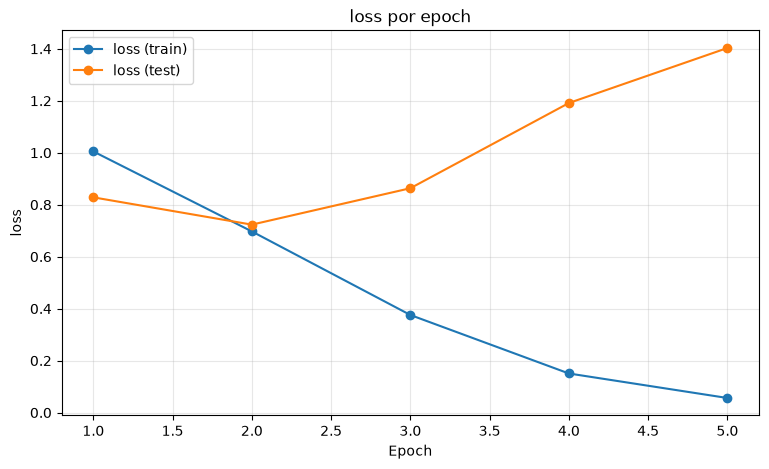

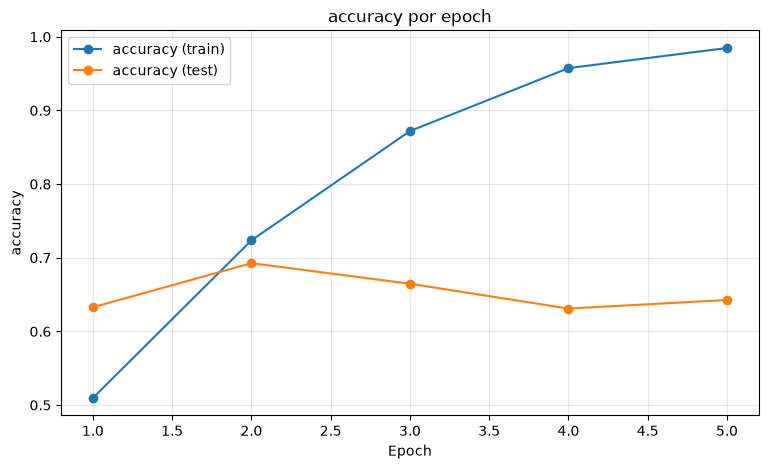

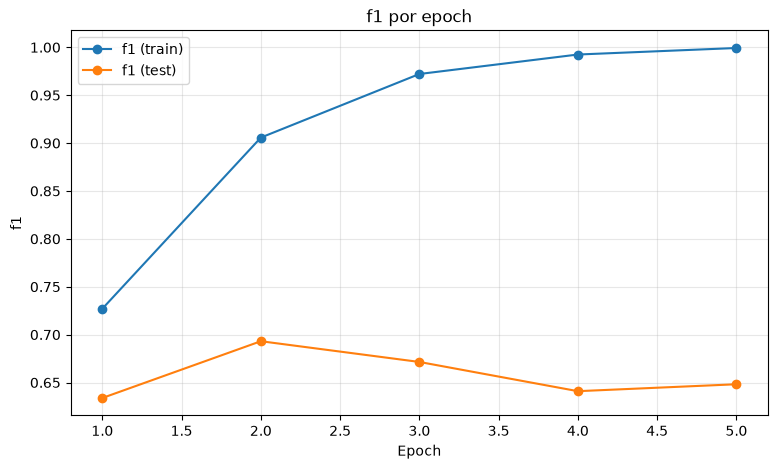

In [8]:
import matplotlib.pyplot as plt
%matplotlib inline

def plot_metric(history, name):
    metric_train = history.history[name]
    metric_test  = history.history[f'val_{name}']
    epochs_range = range(1, len(metric_train) + 1)

    plt.figure(figsize=(9, 5))
    plt.plot(epochs_range, metric_train, marker='o', label=f'{name} (train)')
    plt.plot(epochs_range, metric_test, marker='o', label=f'{name} (test)')
    plt.title(f'{name} por epoch')
    plt.xlabel('Epoch')
    plt.ylabel(name)
    plt.grid(alpha=0.3)
    plt.legend()
    plt.show()

plot_metric(history, 'loss')
plot_metric(history, 'accuracy')
plot_metric(history, 'f1')

---

## 7. Evaluación del modelo

Igual que en el notebook 15, cargamos desde disco el modelo del epoch con mejor F1 de test (no el objeto `model` en memoria, que corresponde al último epoch) y evaluamos con él.

In [9]:
from tensorflow.keras.models import load_model

modelo_mlp_emb = load_model(MODEL_PATH, custom_objects={'KerasLayer': hub.KerasLayer})
print(f'Modelo cargado desde: {MODEL_PATH}')

Modelo cargado desde: models/16_mejor_modelo_mlp_embeddings_reviews.keras


In [10]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, ConfusionMatrixDisplay)

y_pred_test_enc  = np.argmax(modelo_mlp_emb.predict(X_test), axis=-1)
y_pred_train_enc = np.argmax(modelo_mlp_emb.predict(X_train), axis=-1)

y_pred_test  = encoder.inverse_transform(y_pred_test_enc)
y_pred_train = encoder.inverse_transform(y_pred_train_enc)

print('--- Evaluacion en TEST ---')
print(f'Accuracy:  {accuracy_score(y_test, y_pred_test):.4f}')
print(f'Precision: {precision_score(y_test, y_pred_test, average="weighted"):.4f}')
print(f'Recall:    {recall_score(y_test, y_pred_test, average="weighted"):.4f}')
print(f'F1:        {f1_score(y_test, y_pred_test, average="weighted"):.4f}')
print()
print(classification_report(y_test, y_pred_test))

215/215 [==============================] - 1s 4ms/step
--- Evaluacion en TEST ---
Accuracy:  0.6926
Precision: 0.6938
Recall:    0.6926
F1:        0.6931

              precision    recall  f1-score   support

    Negativa       0.70      0.69      0.69       490
      Neutra       0.51      0.52      0.52       447
    Positiva       0.79      0.79      0.79       784

    accuracy                           0.69      1721
   macro avg       0.67      0.67      0.67      1721
weighted avg       0.69      0.69      0.69      1721



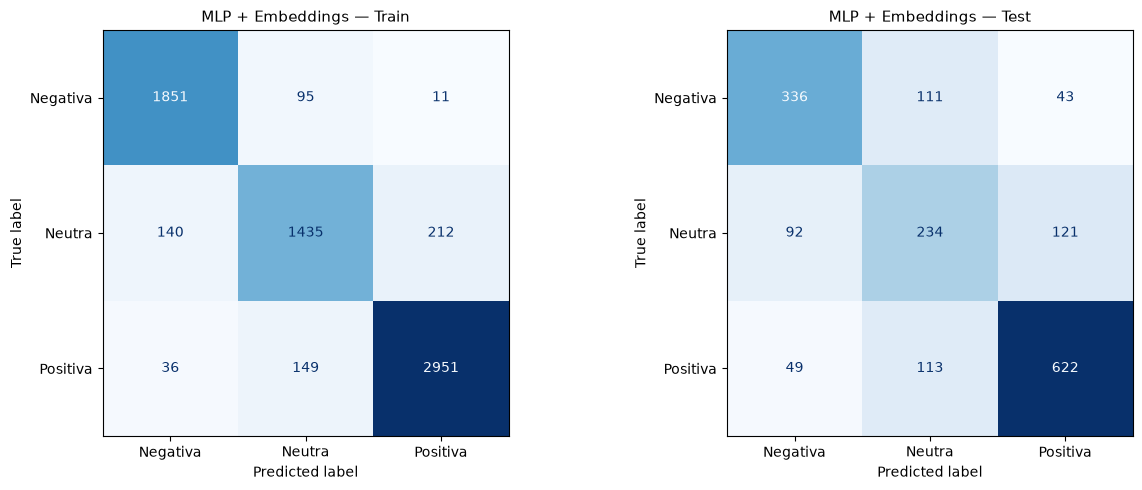

In [11]:
clases = list(encoder.classes_)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_train, y_pred_train,
    display_labels=clases,
    colorbar=False, cmap='Blues', ax=axes[0])
axes[0].set_title('MLP + Embeddings — Train', fontsize=11)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_test,
    display_labels=clases,
    colorbar=False, cmap='Blues', ax=axes[1])
axes[1].set_title('MLP + Embeddings — Test', fontsize=11)

plt.tight_layout()
plt.show()

## Conclusiones

* El `F1Checkpoint` se quedó con el modelo del **epoch 2** (val_f1 = 0.6869). A partir de ahí, el F1 de entrenamiento sube muy rápido hasta 1.0000 en el epoch 10, mientras que el F1 de test nunca vuelve a alcanzar el valor del epoch 2: se queda oscilando entre 0.64 y 0.65 durante los 8 epochs restantes. El sobreajuste llega muy pronto también con este embedding, y el `F1Checkpoint` es lo que nos permite quedarnos con el mejor punto en vez de con el último epoch.

* El modelo cargado desde disco (el del epoch 2) obtiene en test un **accuracy del 68.56 % y un F1 ponderado de 0.6869**, con un F1 de Neutra de 0.52. Esta vez el resultado **mejora** al del notebook 15 con Bag of Words (accuracy 67.46 % / F1 0.6712 / F1 de Neutra 0.47), sobre todo en la clase más difícil de las tres, Neutra, donde pasamos de un F1 de 0.47 a 0.52.

* La hipótesis de partida —que un embedding, al capturar significado en vez de simples frecuencias de palabras, debería producir un modelo mejor que BoW— **sí se cumple aquí**, aunque con un margen modesto (poco más de 1 punto y medio de F1). Ajustar el embedding (`trainable=True`) permite especializar hacia la señal de sentimiento una representación pensada originalmente para significado y similitud temática, y esa especialización aporta algo que BoW, con su enfoque basado puramente en frecuencias de palabras, no puede capturar del todo.

* Esa mejora tiene un coste computacional considerable: 125.020.355 parámetros entrenables y unos 110-115 segundos por epoch en CPU, frente a las ~194.000 conexiones y los pocos segundos por epoch que necesitaba el notebook 15. La elección entre BoW y un embedding preentrenado no es solo una cuestión de qué métrica final es mejor, sino también de cuánto tiempo y capacidad de cómputo se está dispuesto a invertir a cambio de esa mejora.

* Esto confirma la idea general de que los embeddings capturan mejor las relaciones semánticas entre palabras —ya lo vimos en los notebooks 13 y 14—, y en esta tarea de clasificación esa ventaja sí se traduce, con el embedding ajustado a la tarea, en una mejora de accuracy y F1 sobre un método más simple como BoW. El margen de mejora y el coste computacional adicional son, sin embargo, aspectos a tener muy en cuenta al elegir entre ambos enfoques para un problema concreto.